<a href="https://colab.research.google.com/github/Yilalu/cnn_satellite_image_classification/blob/main/cnn_satellite_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convolution Neural NetworkNetwork (CNN)

### Satellite image classification with CNN

#### Project Overview 

- This project implements a Convolutional Neural Network (CNN) using TensorFlow and Keras to perform multiclass classification of satellite imagery. The objective is to classify each satellite image into one of ten distinct land-cover classes. The overall workflow follows a standard deep learning pipeline, including data preparation, preprocessing, model development, training, evaluation, and model optimization.

In [33]:
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

### Dataset Preparation

- The satellite image dataset consists of approximately 27,000 labeled images distributed across 10 classes. Before model development, the dataset is organized into separate training, validation, and testing subsets to ensure an unbiased evaluation of model performance.

The dataset is divided as follows

    - Training Set (80%) – Used to train the CNN model.
    - Validation Set (10%) – Used to monitor the learning process and tune model hyperparameters.
    - Testing Set (10%) – Used only for the final performance evaluation.

- The goal is to train a CNN that can accurately identify the correct class for every input image.
    - AnnualCrop, 
    - Forest, 
    - HerbaceousVegetation
    - Highway
    - Industrial
    - Pasture
    - PermanentCrop
    - Residential
    - River
    - SeaLake

In [34]:
# CONFIGURATION
DATA_DIR= "satellite_data"
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64
NUM_CLASSES = 10

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [35]:
# load the dataset
from pyautogui import size


all_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)
print("Dataset loaded successfully.")
class_names = all_dataset.class_names
print("Number of classes:", len(class_names))
print("Classes found:", class_names)

# Let's print the number of images in each class
class_counts = {class_name: 0 for class_name in class_names}

for images, labels in all_dataset:
    for label in labels.numpy():
        class_counts[class_names[label]] += 1
print("Number of images in each class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")



Found 27000 files belonging to 10 classes.
Dataset loaded successfully.
Number of classes: 10
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of images in each class:
AnnualCrop: 3000
Forest: 3000
HerbaceousVegetation: 3000
Highway: 2500
Industrial: 2500
Pasture: 2000
PermanentCrop: 2500
Residential: 3000
River: 2500
SeaLake: 3000


In [54]:
try:
    train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="training",
    color_mode="rgb",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
    )
    
    valid_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        labels="inferred",
        label_mode="int",
        validation_split=0.2,
        subset="validation",
        color_mode="rgb",
        seed=SEED,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True
    )
except Exception as e:
    print("Error loading dataset:", e)
    exit()




Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


In [61]:
# Let's convert our image dataset to a NumPy array for easier manipulation

for images, labels in train_ds.take(1):
    train_images = images.numpy().astype("uint8")
    train_labels = labels.numpy().astype("int32")
for images, labels in valid_ds.take(1):
    valid_images = images.numpy().astype("uint8")
    valid_labels = labels.numpy().astype("int32")

# Now we can check the shapes of our training and validation datasets
print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Validation images shape:", valid_images.shape)
print("Validation labels shape:", valid_labels.shape)


Training images shape: (64, 128, 128, 3)
Training labels shape: (64,)
Validation images shape: (64, 128, 128, 3)
Validation labels shape: (64,)


In [62]:
# Now let's see what the  numbers for the last 20 images in the training dataset are
print("Last 20 training labels:", train_labels[-20:])
print("Last 20 validation labels:", valid_labels[-20:])

Last 20 training labels: [1 7 4 0 0 9 3 1 4 0 9 0 7 7 2 8 2 7 1 6]
Last 20 validation labels: [1 1 4 9 2 7 3 5 1 6 1 9 0 1 9 8 5 3 7 3]


In [57]:
# Let's count the number of images in each class for both training and validation datasets
train_class_counts = {class_name: 0 for class_name in class_names}

print("*"*40)
print("Class count in full training set")
print("*"*40)
for i, name in enumerate(class_names):
    print(f"{name}: {np.sum(train_labels == i)}")

print("*"*40)
print("Class count in full validation set")
print("*"*40)
for i, name in enumerate(class_names):
    print(f"{name}: {np.sum(valid_labels == i)}")

****************************************
Class count in full training set
****************************************
AnnualCrop: 6
Forest: 9
HerbaceousVegetation: 7
Highway: 5
Industrial: 9
Pasture: 3
PermanentCrop: 8
Residential: 3
River: 5
SeaLake: 9
****************************************
Class count in full validation set
****************************************
AnnualCrop: 7
Forest: 13
HerbaceousVegetation: 3
Highway: 0
Industrial: 8
Pasture: 2
PermanentCrop: 6
Residential: 6
River: 13
SeaLake: 6


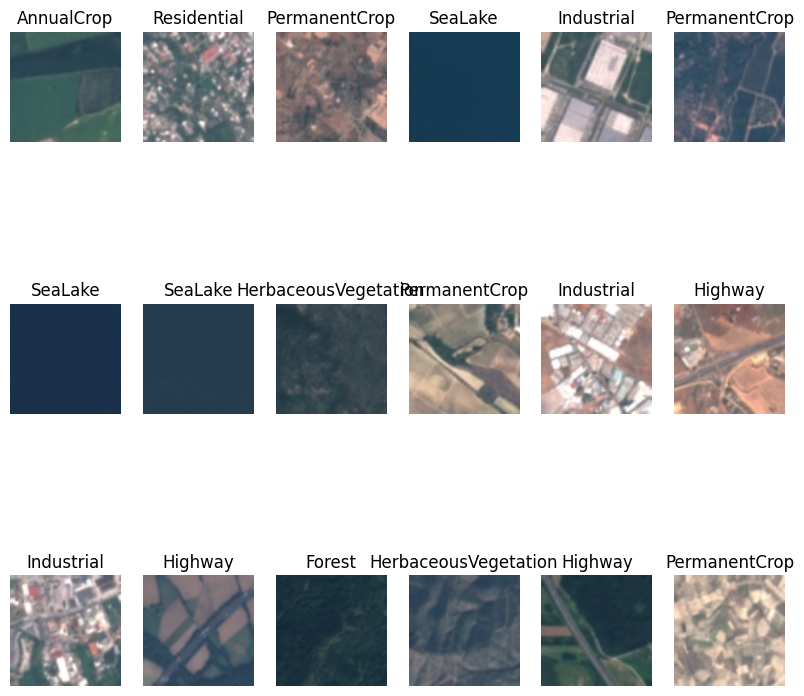

In [58]:
# Let's visualize some of the images in the training dataset along with their labels to ensure that the data is loaded correctly.
plt.figure(figsize=(10, 10))
for i in range(18):
    ax = plt.subplot(3, 6, i + 1)
    plt.imshow(train_images[i].astype("uint8"))
    plt.title(class_names[train_labels[i]])
    plt.axis("off")
plt.show()

### Dataset Preprocessing 

- Data Normalization
- Data Augmentation
- Pipeline Optimization

The pixel values are normalized from the range **0–255** to **0–1** using a rescaling layer. Normalization improves numerical stability during training and helps the model converge more efficiently.


Data augmentation is applied only to the training dataset to increase the diversity of the training images and reduce overfitting. Random transformations such as flipping, rotation, and zooming help the model learn features that are more robust to variations in satellite imagery.

The TensorFlow data pipeline is optimized to improve training performance. The training dataset is shuffled to randomize the order of the images, while caching and prefetching are used to reduce data loading time and improve GPU utilization during training.

In [63]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), # Flip images horizontally with 50% probability
    tf.keras.layers.RandomRotation(0.1),     # Rotate images by up to 10% of a full rotation
    tf.keras.layers.RandomZoom(0.1)          # Zoom into images by up to 10%
])

AUTOTUNE = tf.data.AUTOTUNE # This allows TensorFlow to automatically tune the performance of the data loading pipeline.

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
) # Prefetch data for optimal performance

val_ds = (
    valid_ds
    .cache()
    .prefetch(AUTOTUNE)
) # Prefetch data for optimal performance

### Build the model

A Convolutional Neural Network (CNN) is developed to classify satellite images into 10 different classes. CNNs are effective for image classification because they can automatically learn spatial features such as edges, textures, and patterns from images.

The model consists of multiple convolutional layers followed by max-pooling layers to extract and reduce spatial features. A dropout layer is included to reduce overfitting, and the final dense layer uses a softmax activation function to output the probability distribution across the 10 classes.

The input images have dimensions of 128 × 128 pixels with 3 RGB channels.

In [65]:
image_model = tf.keras.Sequential([
    # Input layer with the shape of the images
    tf.keras.layers.Input(shape=(128, 128, 3)),  # Input layer with the shape of the images

    # Normalization layer to scale pixel values to [0, 1]
    normalization_layer,   
    # Data augmentation layer to apply random transformations to the images during training
    data_augmentation,

    # First Convolutional layer with 32 filters, a kernel size of 3x3, and ReLU activation
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    # MaxPooling layer to reduce the spatial dimensions of the feature maps
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second Convolutional layer with 64 filters, a kernel size of 3x3, and ReLU activation
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    # MaxPooling layer to reduce the spatial dimensions of the feature maps
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third Convolutional layer with 128 filters, a kernel size of 3x3, and ReLU activation
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    # MaxPooling layer to reduce the spatial dimensions of the feature maps
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten layer to convert the 2D feature maps into a 1D feature vector
    tf.keras.layers.Flatten(),

    # Dense layer with 128 units and ReLU activation
    tf.keras.layers.Dense(128, activation='relu'),

    # Output layer with NUM_CLASSES units and softmax activation for multi-class classification
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')

], name="image_model")

# Compile the model with Adam optimizer, sparse categorical crossentropy loss, and accuracy metric
image_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

# Let's print the model summary to see the architecture and number of parameters
image_model.summary()

Model: "image_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,970 (16.36 MB)

 Trainable params: 4,288,970 (16.36 MB)

 Non-trainable params: 0 (0.00 B)